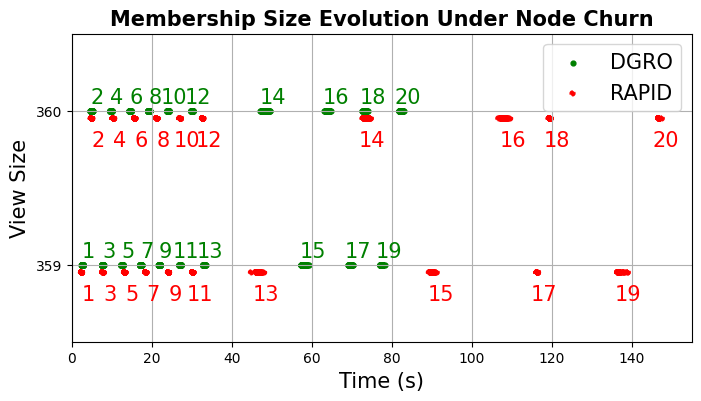

In [12]:
import re

# Define the regex pattern
pattern = r"Port (\d+) \+ view changes to size (\d+) at (\d+) ms"
pattern2 = r"Start time: (\d+) ms"

N = 100
k = 8



import matplotlib.pyplot as plt

# Plot the sorted list
labels = ['DGRO', 'RAPID']
# prefix = ['', '_RANDOM_bk', '_bk']
# prefix = ['_bk', '_RANDOM_bk']
prefix = ['', '_RANDOM']
colors = ['g', 'r', 'b', 'purple']
linestyles = ['-', '--', '-.']
N_list = [100]
for N in N_list:
    fig, ax = plt.subplots(ncols=1, figsize=(8, 4))
    for random in [0, 1, 2]:
        for m in [2, 4, 6]:
            ViewchangeTime = {}
            ViewSize = {}
            start_time = 0
            latency_list = []
            try:
                with open(f"N={N}/N={N}_M={m}{prefix[random]}.txt") as f:
                    lines = f.readlines()
                    for line in lines:
                        # Match the pattern
                        match = re.match(pattern, line)

                        if match:
                            port, size, time_ms = map(int, match.groups())  # Extract values and convert to integers
                            if port not in ViewchangeTime.keys(): 
                                ViewchangeTime[port] = [time_ms]
                                ViewSize[port] = [size + 260]
                            else:
                                ViewchangeTime[port].append(time_ms)
                                ViewSize[port].append(size + 260)
                            # print(f"Port: {port}, Size: {size}, Time (ms): {time_ms}")
                        
                        match = re.match(pattern2, line)

                        if match:
                            start_time = int(match.group(1))
                            # print(line, start_time)
                            for key in ViewchangeTime.keys():
                                for i in range(len(ViewchangeTime[key])):
                                    ViewchangeTime[key][i] = (ViewchangeTime[key][i] - start_time) / 1000
                                    ViewSize[key][i] -= 0.05 * random
                                # latency_list.append(ViewchangeTime[key])
                            break
                        
            
                # path_latency_sorted = sorted(latency_list)
                # print(path_latency_sorted[:5])
                # print(path_latency_sorted[:5], path_latency_sorted[-5:])
                first_scatter = True
                for port in ViewchangeTime.keys():
                    ax.scatter(ViewchangeTime[port], ViewSize[port], linestyle=linestyles[random], 
                    label=f"{labels[random]}" if first_scatter else None,
                    color=colors[random], s=12)
                    if first_scatter:
                        for idx, x_value in enumerate(ViewchangeTime[port]):
                            y_value = ViewSize[port][idx]  # 对应的 y 值
                            ax.annotate(f"{idx + 1}",  # 标注内容为索引 ID
                                        (x_value, y_value),  # 标注的位置
                                        textcoords="offset points",  # 相对偏移
                                        xytext=(5, 5 - 25 * random),  # 偏移量，向右上方移动
                                        fontsize=15,  # 字体大小
                                        ha='center',
                                        color=colors[random])  # 水平居中

                    first_scatter = False
            except:
                pass 
    # ax.set_title('')
    ax.set_xlabel('Time (s)', fontdict={'fontsize':15})
    ax.set_ylabel('View Size', fontdict={'fontsize':15})
    ax.set_title('Membership Size Evolution Under Node Churn', fontdict={'fontsize':15}, weight='bold')
    ax.set_xlim([0, 155])
    ax.set_ylim([98.5 + 260, 100.5 + 260])
    ax.set_yticks([99 + 260, 100 + 260])
    ax.set_yticklabels([99 + 260, 100 + 260])
    ax.legend(fontsize=15)
    ax.grid(True)
    # plt.show()
    fig.savefig(f'Rejoin.pdf', bbox_inches='tight')
